In [1]:
# Import libraries
import subprocess
subprocess.run(["pip", "install", "xgboost"])
subprocess.run(["pip", "install", "imbalanced-learn"])
print("Done")

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Done


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_score,
                             recall_score, f1_score)

In [3]:
# Load the engineered dataset
df_model = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/engineered_features.csv")
df_model.head()

,Tenure Group,Charge Level,Multiple Lines,Tech Support,Internet Service,Online Security,Contract,Churn
0,0,0,0,0,1,0,0,0
1,1,1,0,0,1,1,1,0
2,0,1,0,0,1,1,0,1
3,2,1,0,1,1,1,1,0
4,0,2,0,0,2,0,0,1


In [5]:
# Split features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Features:", X.columns.tolist())
print("Shape:", X.shape)

Features: ['Tenure Group', 'Charge Level', 'Multiple Lines', 'Tech Support', 'Internet Service', 'Online Security', 'Contract']
Shape: (7032, 7)


In [6]:
# Train test split — 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 4922
Test samples: 2110


In [7]:
# Apply SMOTETomek to balance the training data
smotetomek = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smotetomek.fit_resample(X_train, y_train)

print("Class distribution after SMOTETomek:")
print(pd.Series(y_train_balanced).value_counts())

Class distribution after SMOTETomek:
Churn
1    3614
0    3614
Name: count, dtype: int64


In [8]:
# Hyperparameter Tuning — Logistic Regression
# Kept lean — only the most impactful parameters tested
# C controls regularisation strength
# Mettle et al. (2026) and Ramachandran et al. (2026) showed tuning
# significantly improves churn prediction performance

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train_balanced, y_train_balanced)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)
print("Best Cross Validation AUC:", round(lr_grid.best_score_, 2))

Best Logistic Regression Parameters:
{'C': 0.01, 'solver': 'lbfgs'}
Best Cross Validation AUC: 0.84


In [9]:
# Hyperparameter Tuning — SVM
# Kept lean — C and kernel are the two most impactful SVM parameters
# rbf kernel handles non-linear churn patterns better than linear

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train_balanced, y_train_balanced)

print("Best SVM Parameters:")
print(svm_grid.best_params_)
print("Best Cross Validation AUC:", round(svm_grid.best_score_, 2))

Best SVM Parameters:
{'C': 10, 'kernel': 'linear'}
Best Cross Validation AUC: 0.84


In [10]:
# Hyperparameter Tuning — XGBoost
# Kept lean — the three most impactful XGBoost parameters tested
# n_estimators = number of trees, learning_rate = step size, max_depth = tree depth

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train_balanced, y_train_balanced)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)
print("Best Cross Validation AUC:", round(xgb_grid.best_score_, 2))

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best Cross Validation AUC: 0.85


In [11]:
# Build the Tuned Hybrid — using the best parameters found for each model
# This is the final optimised version of the best model from the 70/30 split
# Backed by Omar et al. (2026) and Mettle et al. (2026)

tuned_hybrid = VotingClassifier(
    estimators=[
        ("lr", lr_grid.best_estimator_),
        ("svm", svm_grid.best_estimator_),
        ("xgb", xgb_grid.best_estimator_)
    ],
    voting="soft"
)

tuned_hybrid.fit(X_train_balanced, y_train_balanced)
tuned_hybrid_predictions = tuned_hybrid.predict(X_test)
tuned_hybrid_proba = tuned_hybrid.predict_proba(X_test)[:, 1]

print("=== Tuned Hybrid — LR + SVM + XGBoost ===")
print(classification_report(y_test, tuned_hybrid_predictions, target_names=["No Churn", "Churn"]))

=== Tuned Hybrid — LR + SVM + XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.89      0.72      0.80      1549
       Churn       0.50      0.77      0.60       561

    accuracy                           0.73      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.73      0.74      2110



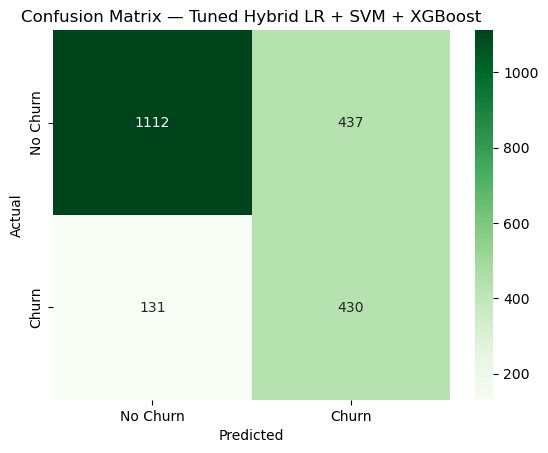

In [12]:
# Confusion Matrix — Tuned Hybrid
cm_tuned = confusion_matrix(y_test, tuned_hybrid_predictions)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Tuned Hybrid LR + SVM + XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# Metrics — Tuned Hybrid
print("=== Tuned Hybrid Metrics ===")
print("Precision :", round(precision_score(y_test, tuned_hybrid_predictions), 2))
print("Recall    :", round(recall_score(y_test, tuned_hybrid_predictions), 2))
print("F1 Score  :", round(f1_score(y_test, tuned_hybrid_predictions), 2))
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_hybrid_proba)
tuned_auc = round(auc(tuned_fpr, tuned_tpr), 2)
print("AUC       :", tuned_auc)

=== Tuned Hybrid Metrics ===
Precision : 0.5
Recall    : 0.77
F1 Score  : 0.6
AUC       : 0.82


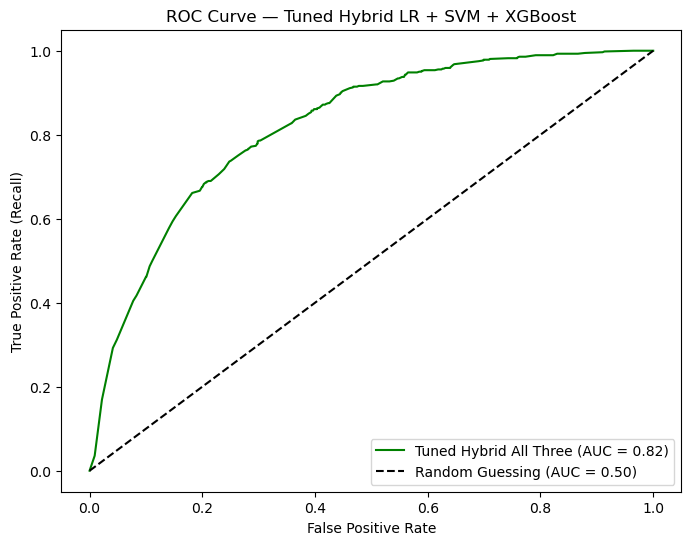

In [14]:
# ROC Curve — Tuned Hybrid vs Untuned Hybrid
plt.figure(figsize=(8, 6))

plt.plot(tuned_fpr, tuned_tpr, label=f"Tuned Hybrid All Three (AUC = {tuned_auc})", color="green")
plt.plot([0, 1], [0, 1], "k--", label="Random Guessing (AUC = 0.50)")

plt.title("ROC Curve — Tuned Hybrid LR + SVM + XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.show()

In [15]:
# Final comparison — Untuned Hybrid All Three vs Tuned Hybrid All Three
comparison = pd.DataFrame({
    "Model": [
        "Untuned Hybrid All Three (70/30)",
        "Tuned Hybrid All Three (70/30)"
    ],
    "Precision": [
        0.51,
        round(precision_score(y_test, tuned_hybrid_predictions), 2)
    ],
    "Recall": [
        0.75,
        round(recall_score(y_test, tuned_hybrid_predictions), 2)
    ],
    "F1 Score": [
        0.60,
        round(f1_score(y_test, tuned_hybrid_predictions), 2)
    ],
    "AUC": [
        0.82,
        tuned_auc
    ]
})

print(comparison.to_string(index=False))

                           Model  Precision  Recall  F1 Score  AUC
Untuned Hybrid All Three (70/30)       0.51    0.75       0.6 0.82
  Tuned Hybrid All Three (70/30)       0.50    0.77       0.6 0.82
